In [1]:
from Python_Libraries import *

In [2]:
# Loading the Datasets

customer_df = pd.read_excel('Customers_dataset.xlsx')
location_df = pd.read_excel('Geolocation_dataset.xlsx')
orders_items_df = pd.read_excel('Order_items_dataset.xlsx')
reviews_df = pd.read_excel('Order_reviews_dataset.xlsx')
orders_df = pd.read_excel('Orders_dataset.xlsx')
products_df = pd.read_excel('Products_dataset.xlsx')

### Pre-Processing for Customer Dataset

In [3]:
# First five rows
print(f"Head: \n{customer_df.head()}\n")
print("-"*70)

# Last five rows
print(f"Tail: \n{customer_df.tail()}\n")
print("-"*70)

# Checking for Duplicates
print(f"Duplicates: \n{customer_df.duplicated().sum()}\n")
print("-"*70)

# Checking for Null Values
print(f"Null Values: \n{customer_df.isnull().sum()}")
print("-"*70)
print(f"Null Values % : \n{customer_df.isnull().mean() * 100}")

Head: 
  customer_id  customer_zip_code  gender age_group customer_segment
0      C00001             690511  Female     36-45            Loyal
1      C00002             509152    Male     26-35              New
2      C00003             477335    Male     26-35            Loyal
3      C00004             140413  Female       65+            Loyal
4      C00005             700009    Male     26-35            Loyal

----------------------------------------------------------------------
Tail: 
      customer_id  customer_zip_code  gender age_group customer_segment
89995      C89996             670691    Male     46-55              New
89996      C89997             755022    Male     26-35              New
89997      C89998             844116    Male     36-45        Returning
89998      C89999             782121    Male     36-45            Loyal
89999      C90000             140103  Female     36-45              New

----------------------------------------------------------------------
Du

In [4]:
# Converting Zip code column into category:
customer_df['customer_zip_code'] = customer_df['customer_zip_code'].astype('category')

In [5]:
# Summary statistics (only for numerical columns)
print("Summary:\n")
print(customer_df.describe())
print("-"*50)


# Dataset structure and info
print("Information:\n")
customer_df.info()
print("-"*50)


# Shape of the dataset (rows, columns)
print("Shape:")
print(customer_df.shape)
print("-"*50)


# Data types of each column
print("Data Types:\n")
print(customer_df.dtypes)
print("-"*50)


# Column names
print("Columns:\n")
print(customer_df.columns)
print("-"*50)

Summary:

       customer_id  customer_zip_code gender age_group customer_segment
count        90000              90000  90000     90000            90000
unique       90000              19238      2         6                3
top         C00001             486441   Male     36-45              New
freq             1                 23  59744     32400            45211
--------------------------------------------------
Information:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90000 entries, 0 to 89999
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   customer_id        90000 non-null  object  
 1   customer_zip_code  90000 non-null  category
 2   gender             90000 non-null  object  
 3   age_group          90000 non-null  object  
 4   customer_segment   90000 non-null  object  
dtypes: category(1), object(4)
memory usage: 3.6+ MB
--------------------------------------------------
Shape:
(90

In [6]:
customer_df['customer_zip_code'].nunique()

19238

<Axes: ylabel='age_group'>

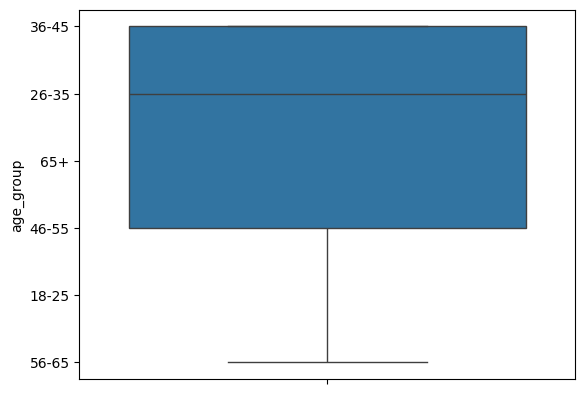

In [7]:
# Outliers Checking
sns.boxplot(y= customer_df['age_group'])


### Pre-Processing for Location Dataset

In [8]:
# First five rows
print(f"Head: \n{location_df.head()}\n")
print("-"*70)

# Last five rows
print(f"Tail: \n{location_df.tail()}\n")
print("-"*70)

# Checking for Duplicates
print(f"Duplicates: \n{location_df.duplicated().sum()}\n")
print("-"*70)

# Checking for Null Values
print(f"Null Values: \n{location_df.isnull().sum()}")
print("-"*70)
print(f"Null Values % : \n{location_df.isnull().mean() * 100}")

Head: 
   geolocation_zip_code geolocation_city          geolocation_state  \
0                744301            Sawai  Andaman & Nicobar Islands   
1                744301              Mus  Andaman & Nicobar Islands   
2                744301           Kakana  Andaman & Nicobar Islands   
3                744301       Carnicobar  Andaman & Nicobar Islands   
4                744301          Lapathy  Andaman & Nicobar Islands   

   geolocation_lat  geolocation_lng region  
0           7.5166          93.6031   East  
1           9.2333          92.7833   East  
2           9.1167          92.8000   East  
3           9.1833          92.7667   East  
4           9.1833          92.7667   East  

----------------------------------------------------------------------
Tail: 
        geolocation_zip_code geolocation_city  \
155540                396240       Chinchpada   
155541                396240            Saily   
155542                396240          Rakholi   
155543               

In [9]:
# Dropping irrelevant columns
# Since a single ZIP code corresponds to multiple localities/villages rather than one unique city, merging on ZIP code creates ambiguity 
# and can skew the data. Therefore, the cities column is being dropped to maintain consistency and avoid inaccurate mappings.

location_df = location_df.drop(columns = ['geolocation_lat', 'geolocation_lng', 'geolocation_city'])


In [10]:
location_df.duplicated().sum()

np.int64(136275)

In [11]:
# Dropping duplicates values
location_df.drop_duplicates(inplace = True)

# Rechecking
location_df.duplicated().sum()

np.int64(0)

In [12]:
# Summary statistics (only for numerical columns)
print("Summary:\n")
print(location_df.describe())
print("-"*50)


# Dataset structure and info
print("Information:\n")
location_df.info()
print("-"*50)


# Shape of the dataset (rows, columns)
print("Shape:")
print(location_df.shape)
print("-"*50)


# Data types of each column
print("Data Types:\n")
print(location_df.dtypes)
print("-"*50)


# Column names
print("Columns:\n")
print(location_df.columns)
print("-"*50)

Summary:

       geolocation_zip_code
count          19270.000000
mean          515937.124909
std           203852.475077
min           110001.000000
25%           370056.250000
50%           523329.500000
75%           686121.750000
max           855117.000000
--------------------------------------------------
Information:

<class 'pandas.core.frame.DataFrame'>
Index: 19270 entries, 0 to 155537
Data columns (total 3 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   geolocation_zip_code  19270 non-null  int64 
 1   geolocation_state     19270 non-null  object
 2   region                19270 non-null  object
dtypes: int64(1), object(2)
memory usage: 602.2+ KB
--------------------------------------------------
Shape:
(19270, 3)
--------------------------------------------------
Data Types:

geolocation_zip_code     int64
geolocation_state       object
region                  object
dtype: object
---------------------------

In [13]:
location_df.head()

,geolocation_zip_code,geolocation_state,region
0,744301,Andaman & Nicobar Islands,East
5,744302,Andaman & Nicobar Islands,East
11,744303,Andaman & Nicobar Islands,East
16,744304,Andaman & Nicobar Islands,East
19,744201,Andaman & Nicobar Islands,East


In [14]:
location_df['geolocation_zip_code'].nunique()

19238

### Pre-Processing for Orders Items Dataset

In [15]:
# First five rows
print(f"Head: \n{orders_items_df.head()}\n")
print("-"*70)

# Last five rows
print(f"Tail: \n{orders_items_df.tail()}\n")
print("-"*70)

# Checking for Duplicates
print(f"Duplicates: \n{orders_items_df.duplicated().sum()}\n")
print("-"*70)

# Checking for Null Values
print(f"Null Values: \n{orders_items_df.isnull().sum()}")
print("-"*70)
print(f"Null Values % : \n{orders_items_df.isnull().mean() * 100}")

Head: 
  order_item_id order_id  quantity product_id  unit_price  discount(%)  \
0      OI000001   O00001         1     P28355        7020         6.54   
1      OI000002   O00002         1     P04408        7590        20.56   
2      OI000003   O00002         2     P14887       14360        24.67   
3      OI000004   O00003         2     P02014        1530        12.06   
4      OI000005   O00003         1     P27255        1560        10.51   

   shipping_cost  
0         713.72  
1        1212.02  
2        1478.39  
3         155.12  
4         188.03  

----------------------------------------------------------------------
Tail: 
       order_item_id order_id  quantity product_id  unit_price  discount(%)  \
149995      OI149996   O66516         2     P29772        2780         5.47   
149996      OI149997   O66516         1     P07149         110         2.68   
149997      OI149998   O66516         2     P09599         290         4.76   
149998      OI149999   O66517         1

In [16]:
# Summary statistics (only for numerical columns)
print("Summary:\n")
print(orders_items_df.describe())
print("-"*50)


# Dataset structure and info
print("Information:\n")
orders_items_df.info()
print("-"*50)


# Shape of the dataset (rows, columns)
print("Shape:")
print(orders_items_df.shape)
print("-"*50)


# Data types of each column
print("Data Types:\n")
print(orders_items_df.dtypes)
print("-"*50)


# Column names
print("Columns:\n")
print(orders_items_df.columns)
print("-"*50)

Summary:

           quantity     unit_price    discount(%)  shipping_cost
count  150000.00000  150000.000000  150000.000000  150000.000000
mean        1.28356    6781.045333      13.526562     722.353992
std         0.52342   12494.025679       9.086881    1610.289245
min         1.00000      50.000000       0.000000       5.000000
25%         1.00000    2020.000000       6.730000     178.320000
50%         1.00000    4030.000000      12.280000     380.930000
75%         1.00000    7640.000000      18.670000     739.080000
max         3.00000  149760.000000      52.490000   29830.680000
--------------------------------------------------
Information:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   order_item_id  150000 non-null  object 
 1   order_id       150000 non-null  object 
 2   quantity       150000 non-null  int64  
 3   

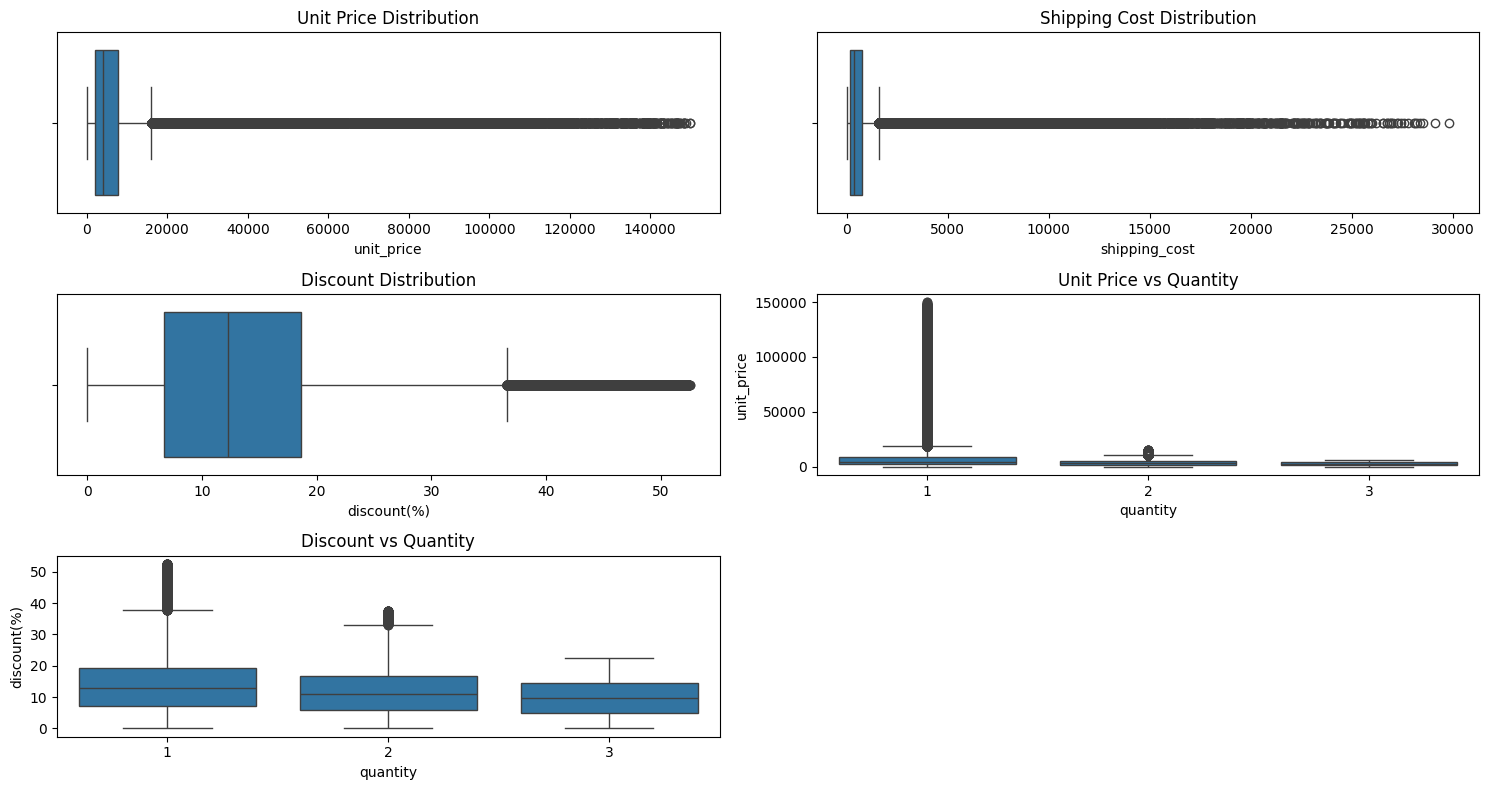

In [17]:
# Outliers Checking

fig, axes = plt.subplots(3, 2, figsize=(15,8))

sns.boxplot(x=orders_items_df['unit_price'], ax=axes[0,0])
axes[0,0].set_title("Unit Price Distribution")

sns.boxplot(x=orders_items_df['shipping_cost'], ax=axes[0,1])
axes[0,1].set_title("Shipping Cost Distribution")


sns.boxplot(x=orders_items_df['discount(%)'], ax=axes[1,0])
axes[1,0].set_title("Discount Distribution")

sns.boxplot(x='quantity', y='unit_price', data=orders_items_df, ax=axes[1,1])
axes[1,1].set_title("Unit Price vs Quantity")


sns.boxplot(x='quantity', y='discount(%)', data=orders_items_df, ax=axes[2,0])
axes[2,0].set_title("Discount vs Quantity")

#remove empty subplot
fig.delaxes(axes[2,1])

plt.tight_layout()
plt.show()

### Pre-Processing for Orders  Dataset

In [18]:
# First five rows
print(f"Head: \n{orders_df.head()}\n")
print("-"*70)

# Last five rows
print(f"Tail: \n{orders_df.tail()}\n")
print("-"*70)

# Checking for Duplicates
print(f"Duplicates: \n{orders_df.duplicated().sum()}\n")
print("-"*70)

# Checking for Null Values
print(f"Null Values: \n{orders_df.isnull().sum()}")
print("-"*70)
print(f"Null Values % : \n{orders_df.isnull().mean() * 100}")

Head: 
  order_id customer_id order_status payment_type order_purchase_timestamp  \
0   O00001      C60210    delivered  Net Banking               2024-11-04   
1   O00002      C01893    delivered  Net Banking               2023-09-01   
2   O00003      C19454    cancelled          UPI               2021-08-06   
3   O00004      C67148    delivered          UPI               2025-07-07   
4   O00005      C56280    delivered  Net Banking               2024-03-30   

  order_approved_at order_delivered_shipping_date  \
0        2024-11-04                    2024-12-01   
1        2023-09-01                    2023-10-01   
2               NaT                           NaT   
3        2025-07-07                    2025-10-06   
4        2024-03-30                    2024-03-31   

  order_delivered_customer_date order_estimated_delivery_date  
0                    2025-03-04                    2025-01-03  
1                    2023-10-05                    2023-10-31  
2                  

In [19]:
# Summary statistics (only for numerical columns)
print("Summary:\n")
print(orders_df.describe())
print("-"*50)


# Dataset structure and info
print("Information:\n")
orders_df.info()
print("-"*50)


# Shape of the dataset (rows, columns)
print("Shape:")
print(orders_df.shape)
print("-"*50)


# Data types of each column
print("Data Types:\n")
print(orders_df.dtypes)
print("-"*50)


# Column names
print("Columns:\n")
print(orders_df.columns)
print("-"*50)

Summary:

            order_purchase_timestamp              order_approved_at  \
count                          99999                          94951   
mean   2023-07-24 21:45:12.015120384  2023-08-06 06:09:56.240165888   
min              2021-04-01 00:00:00            2021-04-01 00:00:00   
25%              2022-07-09 00:00:00            2022-07-19 00:00:00   
50%              2023-08-26 00:00:00            2023-09-08 00:00:00   
75%              2024-09-22 00:00:00            2024-10-04 00:00:00   
max              2025-09-30 00:00:00            2026-01-26 00:00:00   

       order_delivered_shipping_date  order_delivered_customer_date  \
count                          94951                          91971   
mean   2023-09-12 09:48:11.230213376  2023-10-04 20:09:28.822780928   
min              2021-04-01 00:00:00            2021-04-04 00:00:00   
25%              2022-08-22 00:00:00            2022-09-11 00:00:00   
50%              2023-10-13 00:00:00            2023-10-31 00:00:0

In [20]:
orders_df['order_status'].value_counts()

order_status
delivered    84971
returned      7000
cancelled     5048
shipped       2980
Name: count, dtype: int64

In [21]:
not_delivered =  (orders_df['order_status'] == 'cancelled') + (orders_df['order_status'] == 'shipped')
not_delivered.sum()

np.int64(8028)

In [22]:
# We are keeping the null values because those orders not delivered and we don't have to deal with those columns.

### Pre-Processing for Reviews Dataset

In [23]:
# First five rows
print(f"Head: \n{reviews_df.head()}\n")
print("-"*70)

# Last five rows
print(f"Tail: \n{reviews_df.tail()}\n")
print("-"*70)

# Checking for Duplicates
print(f"Duplicates: \n{reviews_df.duplicated().sum()}\n")
print("-"*70)

# Checking for Null Values
print(f"Null Values: \n{reviews_df.isnull().sum()}")
print("-"*70)
print(f"Null Values % : \n{reviews_df.isnull().mean() * 100}")

Head: 
  review_id order_id  review_score              review_comment_message  \
0    R00001   O41195             5                                 NaN   
1    R00002   O29304             5      Order cancelled by the seller.   
2    R00003   O57427             5  Payment issue led to cancellation.   
3    R00004   O12705             5                                 NaN   
4    R00005   O43324             1                                 NaN   

  review_date  
0         NaT  
1         NaT  
2         NaT  
3  2022-10-22  
4         NaT  

----------------------------------------------------------------------
Tail: 
      review_id order_id  review_score             review_comment_message  \
97014    R97015   O65098             5                                NaN   
97015    R97016   O63251             5                                NaN   
97016    R97017   O18273             1                                NaN   
97017    R97018   O28898             4                           

In [24]:
# Summary statistics (only for numerical columns)
print("Summary:\n")
print(reviews_df.describe())
print("-"*50)


# Dataset structure and info
print("Information:\n")
reviews_df.info()
print("-"*50)


# Shape of the dataset (rows, columns)
print("Shape:")
print(reviews_df.shape)
print("-"*50)


# Data types of each column
print("Data Types:\n")
print(reviews_df.dtypes)
print("-"*50)


# Column names
print("Columns:\n")
print(reviews_df.columns)
print("-"*50)

Summary:

       review_score                    review_date
count  97019.000000                          49465
mean       4.090807  2023-09-26 13:13:34.757909760
min        1.000000            2021-01-04 00:00:00
25%        4.000000            2022-09-07 00:00:00
50%        5.000000            2023-10-14 00:00:00
75%        5.000000            2024-11-08 00:00:00
max        5.000000            2026-12-15 00:00:00
std        1.345705                            NaN
--------------------------------------------------
Information:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 97019 entries, 0 to 97018
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   review_id               97019 non-null  object        
 1   order_id                97019 non-null  object        
 2   review_score            97019 non-null  int64         
 3   review_comment_message  56169 non-null  object       

In [25]:
# Treatment of Null Values

# Here, it means the customer didn’t write a comment, not missing data.
reviews_df['review_comment_message'] = reviews_df['review_comment_message'].fillna('No Comment')


#Since reviews occur post-delivery, missing review dates were imputed using delivery date plus an average delay of 2 days to preserve temporal consistency.
reviews_df['review_date'] = reviews_df['review_date'].fillna(orders_df['order_delivered_customer_date'] + pd.Timedelta(days=2))


# Rechecking Null Values
reviews_df.isnull().sum()

review_id                    0
order_id                     0
review_score                 0
review_comment_message       0
review_date               3871
dtype: int64

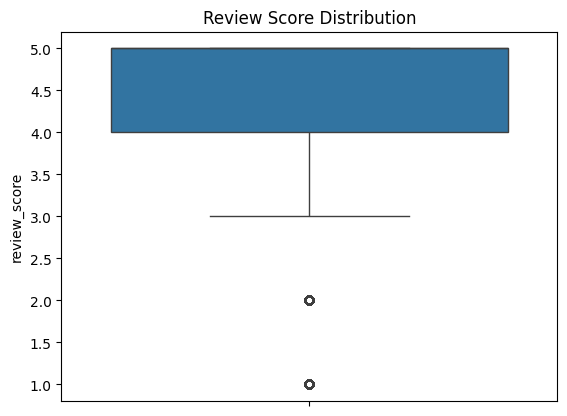

In [26]:
# Outliers Checking
sns.boxplot(y=reviews_df['review_score'])
plt.title("Review Score Distribution")
plt.show()

### Pre-Processing for Products Dataset

In [27]:
# First five rows
print(f"Head: \n{products_df.head()}\n")
print("-"*70)

# Last five rows
print(f"Tail: \n{products_df.tail()}\n")
print("-"*70)

# Checking for Duplicates
print(f"Duplicates: \n{products_df.duplicated().sum()}\n")
print("-"*70)

# Checking for Null Values
print(f"Null Values: \n{products_df.isnull().sum()}")
print("-"*70)
print(f"Null Values % : \n{products_df.isnull().mean() * 100}")

Head: 
  product_id   Category_name    sub_category_name  product_weight_g  \
0     P00001       perfumery           Fragrances               225   
1     P00002             art  General Merchandise              1000   
2     P00003  sports_leisure  General Merchandise               154   
3     P00004            baby         Collectibles               371   
4     P00005      housewares        Novelty Items               625   

            brand  cost_price  selling_price stock_availability  
0           Nivea        2200           2860           In Stock  
1  Generic Global         110            140           In Stock  
2  Generic Indian       14680          17170           In Stock  
3  Generic Indian        3890           4920           In Stock  
4  Generic Indian       12590          16220           In Stock  

----------------------------------------------------------------------
Tail: 
      product_id           Category_name sub_category_name  product_weight_g  \
32946     P

In [28]:
# Summary statistics (only for numerical columns)
print("Summary:\n")
print(products_df.describe())
print("-"*50)


# Dataset structure and info
print("Information:\n")
products_df.info()
print("-"*50)


# Shape of the dataset (rows, columns)
print("Shape:")
print(products_df.shape)
print("-"*50)


# Data types of each column
print("Data Types:\n")
print(products_df.dtypes)
print("-"*50)


# Column names
print("Columns:\n")
print(products_df.columns)
print("-"*50)

Summary:

       product_weight_g     cost_price  selling_price
count      32951.000000   32951.000000   32951.000000
mean        2278.448514   16498.051319   20421.360505
std         4285.771330   23833.271209   29336.864189
min            2.000000      40.000000      50.000000
25%          300.000000    3315.000000    4340.000000
50%          700.000000    8420.000000   10560.000000
75%         1900.000000   13890.000000   17250.000000
max        40425.000000  133140.000000  149760.000000
--------------------------------------------------
Information:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   product_id          32951 non-null  object
 1   Category_name       32951 non-null  object
 2   sub_category_name   32951 non-null  object
 3   product_weight_g    32951 non-null  int64 
 4   brand               32951 non-null  ob

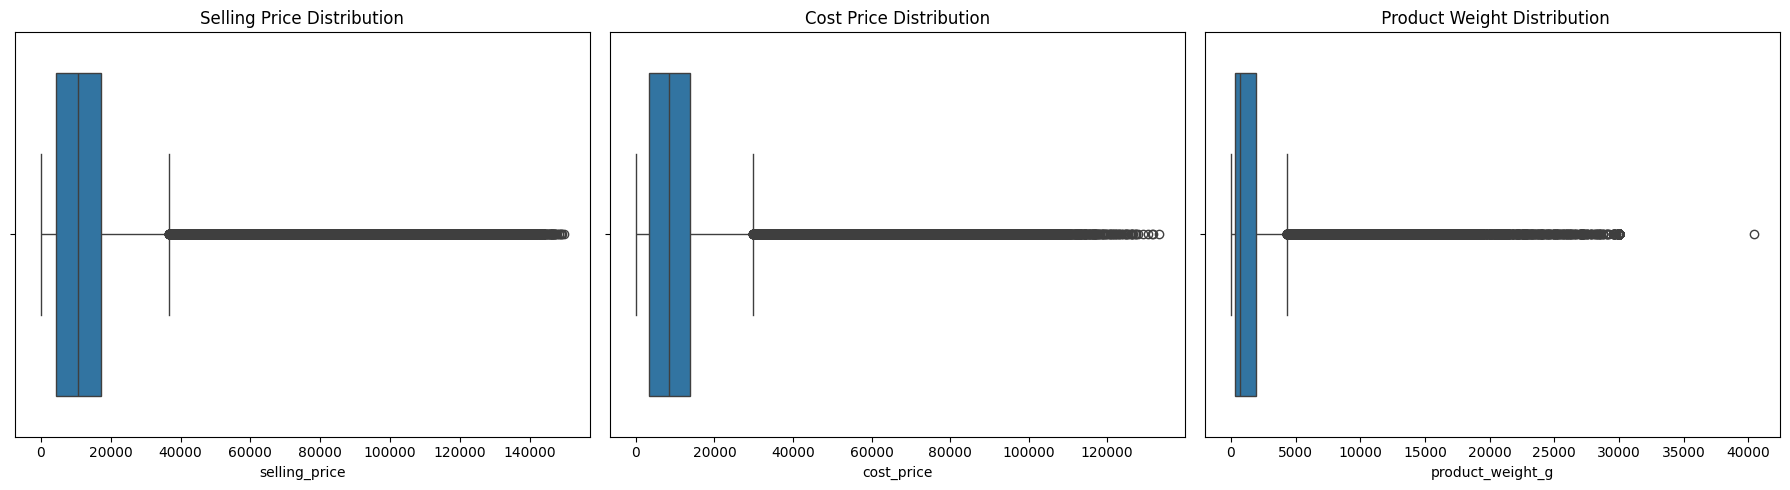

In [29]:
# Outliers Checking

fig, axes = plt.subplots(1, 3, figsize=(18,5))

sns.boxplot(x=products_df['selling_price'], ax=axes[0])
axes[0].set_title("Selling Price Distribution")

sns.boxplot(x=products_df['cost_price'], ax=axes[1])
axes[1].set_title("Cost Price Distribution")

sns.boxplot(x=products_df['product_weight_g'], ax=axes[2])
axes[2].set_title(" Product Weight Distribution")

plt.tight_layout()
plt.show()

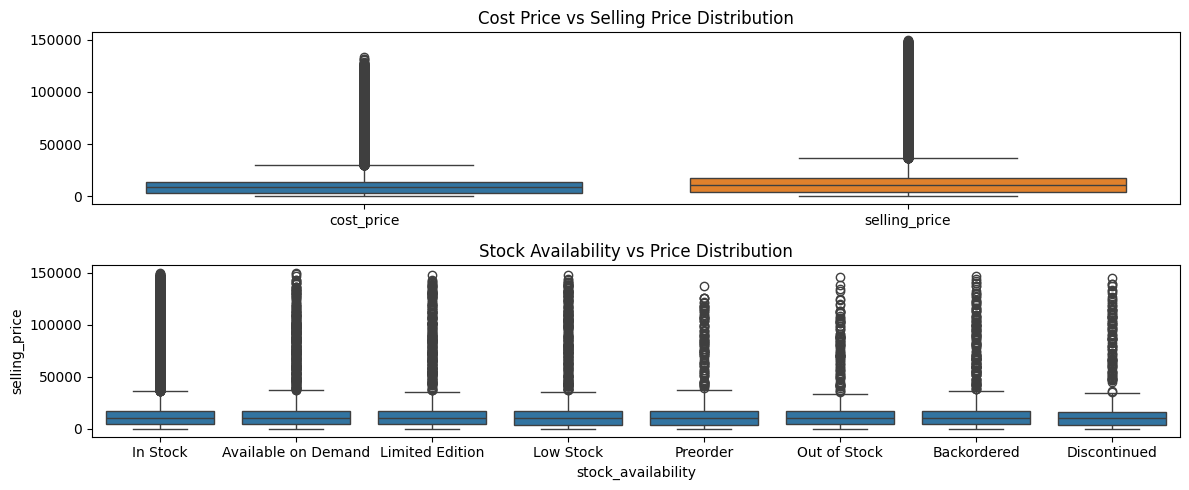

In [30]:
fig, axes = plt.subplots(2, 1, figsize=(12,5))

sns.boxplot(data=products_df[['cost_price','selling_price']], ax=axes[0])
axes[0].set_title("Cost Price vs Selling Price Distribution")

sns.boxplot(x='stock_availability', y='selling_price', data=products_df, ax=axes[1])
axes[1].set_title("Stock Availability vs Price Distribution")

plt.tight_layout()
plt.show()

### Now, the data is all preprocessed and cleaned.

In [31]:

customer_df.to_csv('Cleaned_Customers_dataset.csv', index=False)
location_df.to_csv('Cleaned_Geolocation_dataset.csv', index=False)
orders_items_df.to_csv('Cleaned_Order_items_dataset.csv', index=False)
reviews_df.to_csv('Cleaned_Order_reviews_dataset.csv', index=False)
orders_df.to_csv('Cleaned_Orders_dataset.csv', index=False)
products_df.to_csv('Cleaned_Products_dataset.csv', index=False)

In [32]:
# MERGING ALL CLEANED DATASETS

# 1. Merge Orders + Customers
merged_df = orders_df.merge(customer_df,on='customer_id',how='left')

# 2. Merge Order Items
merged_df = merged_df.merge(orders_items_df, on='order_id',how='left')

# 3. Merge Products
merged_df = merged_df.merge( products_df, on='product_id', how='left')

# 4. Merge Reviews
merged_df = merged_df.merge(reviews_df, on='order_id', how='left')

# 5. Merge Location 
merged_df = merged_df.merge(location_df, left_on='customer_zip_code', right_on='geolocation_zip_code',how='left')


# CHECK FINAL DATASET

print("Shape of merged dataset:", merged_df.shape)

# View first 5 rows
merged_df.head()

# SAVE FINAL MERGED DATASET

merged_df.to_csv("ecommerce_merged_dataset.csv", index=False)
print("Merged dataset saved successfully!")

Shape of merged dataset: (183784, 33)
Merged dataset saved successfully!


In [33]:
merged_df[merged_df['customer_zip_code']==413514]

,order_id,customer_id,order_status,payment_type,order_purchase_timestamp,order_approved_at,order_delivered_shipping_date,order_delivered_customer_date,order_estimated_delivery_date,customer_zip_code,...,cost_price,selling_price,stock_availability,review_id,review_score,review_comment_message,review_date,geolocation_zip_code,geolocation_state,region
0,O00001,C60210,delivered,Net Banking,2024-11-04,2024-11-04,2024-12-01,2025-03-04,2025-01-03,413514,...,5330.0,7020.0,In Stock,R89199,1.0,Item arrived damaged.,2025-04-05,413514,Maharashtra,West
14051,O06184,C60210,shipped,Credit Card,2023-12-03,2024-02-01,2024-03-03,NaT,2023-12-12,413514,...,4330.0,6050.0,In Stock,NaN,NaN,NaN,NaT,413514,Maharashtra,West
14052,O06184,C60210,shipped,Credit Card,2023-12-03,2024-02-01,2024-03-03,NaT,2023-12-12,413514,...,130.0,220.0,In Stock,NaN,NaN,NaN,NaT,413514,Maharashtra,West
14053,O06184,C60210,shipped,Credit Card,2023-12-03,2024-02-01,2024-03-03,NaT,2023-12-12,413514,...,2210.0,2620.0,In Stock,NaN,NaN,NaN,NaT,413514,Maharashtra,West
14054,O06184,C60210,shipped,Credit Card,2023-12-03,2024-02-01,2024-03-03,NaT,2023-12-12,413514,...,1620.0,2380.0,In Stock,NaN,NaN,NaN,NaT,413514,Maharashtra,West
84641,O37500,C11979,returned,UPI,2025-02-26,2025-02-26,2025-04-28,2025-04-29,2025-04-27,413514,...,920.0,1190.0,In Stock,R90307,5.0,Returned as product did not match description.,2021-09-06,413514,Maharashtra,West
84642,O37500,C11979,returned,UPI,2025-02-26,2025-02-26,2025-04-28,2025-04-29,2025-04-27,413514,...,1570.0,1860.0,In Stock,R90307,5.0,Returned as product did not match description.,2021-09-06,413514,Maharashtra,West
120672,O53471,C76602,delivered,UPI,2021-07-15,2021-07-15,2021-07-15,2021-07-18,2021-07-20,413514,...,10850.0,14280.0,In Stock,R14252,4.0,Great product and quick delivery.,2021-11-27,413514,Maharashtra,West
180969,O97189,C76602,delivered,UPI,2023-07-26,2023-07-26,2023-10-26,2023-11-02,2023-08-04,413514,...,NaN,NaN,NaN,R10182,5.0,No Comment,2023-02-24,413514,Maharashtra,West
182688,O98907,C60210,delivered,UPI,2023-11-26,2023-11-26,2023-11-27,2023-11-28,2023-12-10,413514,...,NaN,NaN,NaN,R41448,5.0,No Comment,2022-05-07,413514,Maharashtra,West


In [34]:
merged_df[merged_df['customer_id']=='C60210']

,order_id,customer_id,order_status,payment_type,order_purchase_timestamp,order_approved_at,order_delivered_shipping_date,order_delivered_customer_date,order_estimated_delivery_date,customer_zip_code,...,cost_price,selling_price,stock_availability,review_id,review_score,review_comment_message,review_date,geolocation_zip_code,geolocation_state,region
0,O00001,C60210,delivered,Net Banking,2024-11-04,2024-11-04,2024-12-01,2025-03-04,2025-01-03,413514,...,5330.0,7020.0,In Stock,R89199,1.0,Item arrived damaged.,2025-04-05,413514,Maharashtra,West
14051,O06184,C60210,shipped,Credit Card,2023-12-03,2024-02-01,2024-03-03,NaT,2023-12-12,413514,...,4330.0,6050.0,In Stock,NaN,NaN,NaN,NaT,413514,Maharashtra,West
14052,O06184,C60210,shipped,Credit Card,2023-12-03,2024-02-01,2024-03-03,NaT,2023-12-12,413514,...,130.0,220.0,In Stock,NaN,NaN,NaN,NaT,413514,Maharashtra,West
14053,O06184,C60210,shipped,Credit Card,2023-12-03,2024-02-01,2024-03-03,NaT,2023-12-12,413514,...,2210.0,2620.0,In Stock,NaN,NaN,NaN,NaT,413514,Maharashtra,West
14054,O06184,C60210,shipped,Credit Card,2023-12-03,2024-02-01,2024-03-03,NaT,2023-12-12,413514,...,1620.0,2380.0,In Stock,NaN,NaN,NaN,NaT,413514,Maharashtra,West
182688,O98907,C60210,delivered,UPI,2023-11-26,2023-11-26,2023-11-27,2023-11-28,2023-12-10,413514,...,NaN,NaN,NaN,R41448,5.0,No Comment,2022-05-07,413514,Maharashtra,West


In [35]:
merged_df.duplicated().sum()

np.int64(0)

In [36]:
location_df.columns

Index(['geolocation_zip_code', 'geolocation_state', 'region'], dtype='object')

In [37]:
merged_df['order_id'].nunique()

99999

In [38]:
merged_df.columns

Index(['order_id', 'customer_id', 'order_status', 'payment_type',
       'order_purchase_timestamp', 'order_approved_at',
       'order_delivered_shipping_date', 'order_delivered_customer_date',
       'order_estimated_delivery_date', 'customer_zip_code', 'gender',
       'age_group', 'customer_segment', 'order_item_id', 'quantity',
       'product_id', 'unit_price', 'discount(%)', 'shipping_cost',
       'Category_name', 'sub_category_name', 'product_weight_g', 'brand',
       'cost_price', 'selling_price', 'stock_availability', 'review_id',
       'review_score', 'review_comment_message', 'review_date',
       'geolocation_zip_code', 'geolocation_state', 'region'],
      dtype='object')